In [ ]:
#install.packages('ISLR')
#install.packages('gam')

In [10]:
# IMPORT LIBRARIES
library(ISLR)
library(gam)
library(splines)
library(tidyverse)
library(caret)


Warning message:
“package ‘gam’ was built under R version 4.5.2”
Loading required package: splines

Loading required package: foreach

Loaded gam 1.22-7


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ purrr::accumulate() masks foreach::accumulate()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
✖ purrr::when()       masks foreach::when()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




# Part-1: Demonstration

## Polynomial Regression

### Example 1

Make a sequence of x values to build model matrices.
Also make a nonlinear response variable and store everything in a data frame.

[1] 601   2


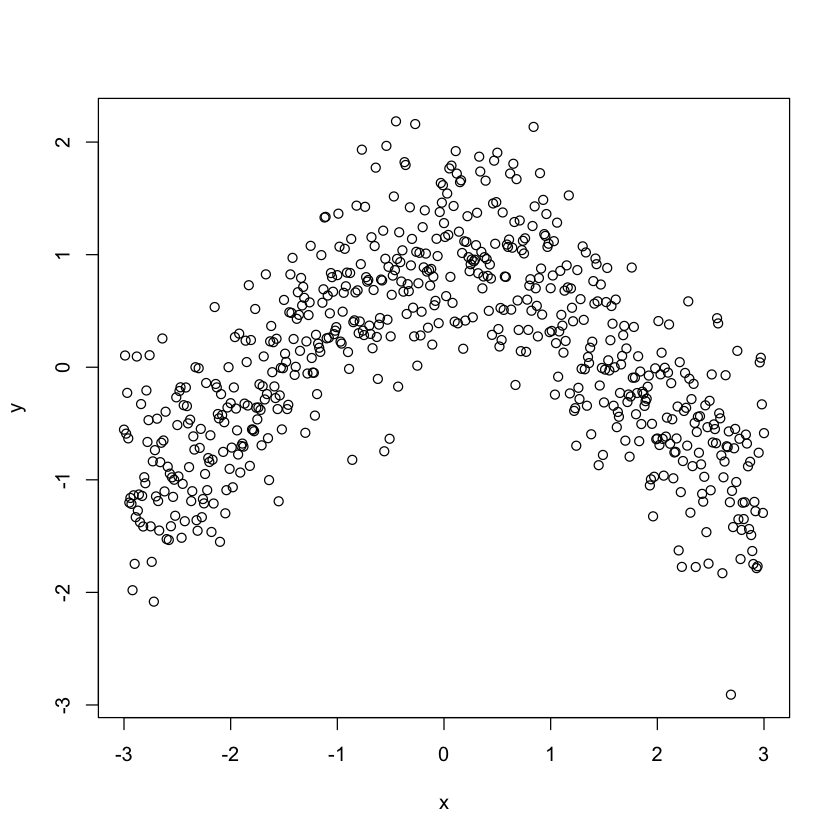

In [2]:
# GENERATE SOME DATA AND PLOT
x = seq(-3,3, by=.01) #random numbers
y = cos(x) + rnorm(length(x))/2 #non-linear function
mydf = data.frame(x = x, y = y)
print(dim(mydf))
plot(mydf)

Make the model matrix for simple linear regression.

In [3]:
# ADD UNIT FEATURE
X1 = model.matrix(y ~ x) #create a design matrix
print(head(X1))

  (Intercept)     x
1           1 -3.00
2           1 -2.99
3           1 -2.98
4           1 -2.97
5           1 -2.96
6           1 -2.95


Make a model matrix for polynomial regression.
The basis functions are the powers of the X variable.

In [4]:
# ADD UNIT FEATURE AND TRANSFORM
X6 = model.matrix(y ~ x + I(x^2) + I(x^3) + I(x^4) + I(x^5) + I(x^6))
print(head(X6))

  (Intercept)     x I(x^2)    I(x^3)   I(x^4)    I(x^5)   I(x^6)
1           1 -3.00 9.0000 -27.00000 81.00000 -243.0000 729.0000
2           1 -2.99 8.9401 -26.73090 79.92539 -238.9769 714.5410
3           1 -2.98 8.8804 -26.46359 78.86150 -235.0073 700.3217
4           1 -2.97 8.8209 -26.19807 77.80828 -231.0906 686.3390
5           1 -2.96 8.7616 -25.93434 76.76563 -227.2263 672.5898
6           1 -2.95 8.7025 -25.67238 75.73351 -223.4138 659.0708


Also make a similar model matrix using the poly() function.
This also makes basis functions which are polynomials of increasing degree.
However, these basis functions have better numerical and statistical properties as we will see shortly.

In [5]:
X6p = model.matrix(y ~ poly(x,6))
print(head(X6))
print(head(X6p)) #values are different

  (Intercept)     x I(x^2)    I(x^3)   I(x^4)    I(x^5)   I(x^6)
1           1 -3.00 9.0000 -27.00000 81.00000 -243.0000 729.0000
2           1 -2.99 8.9401 -26.73090 79.92539 -238.9769 714.5410
3           1 -2.98 8.8804 -26.46359 78.86150 -235.0073 700.3217
4           1 -2.97 8.8209 -26.19807 77.80828 -231.0906 686.3390
5           1 -2.96 8.7616 -25.93434 76.76563 -227.2263 672.5898
6           1 -2.95 8.7025 -25.67238 75.73351 -223.4138 659.0708


  (Intercept) poly(x, 6)1 poly(x, 6)2 poly(x, 6)3 poly(x, 6)4 poly(x, 6)5
1           1 -0.07053437  0.09075695 -0.10685037   0.1203532  -0.1319531
2           1 -0.07029925  0.08984938 -0.10471337   0.1163415  -0.1253555
3           1 -0.07006414  0.08894484 -0.10259420   0.1123900  -0.1189120
4           1 -0.06982902  0.08804333 -0.10049281   0.1084983  -0.1126207
5           1 -0.06959391  0.08714486 -0.09840913   0.1046659  -0.1064795
6           1 -0.06935879  0.08624941 -0.09634312   0.1008924  -0.1004863
  poly(x, 6)6
1  0.14202315
2  0.13208153
3  0.12247185
4  0.11318745
5  0.10422175
6  0.09556826


Make a plot of the basis functions x, x^2, ..., x^6.
Since these values are fairly large near the ends of the interval, we need a large ylim.


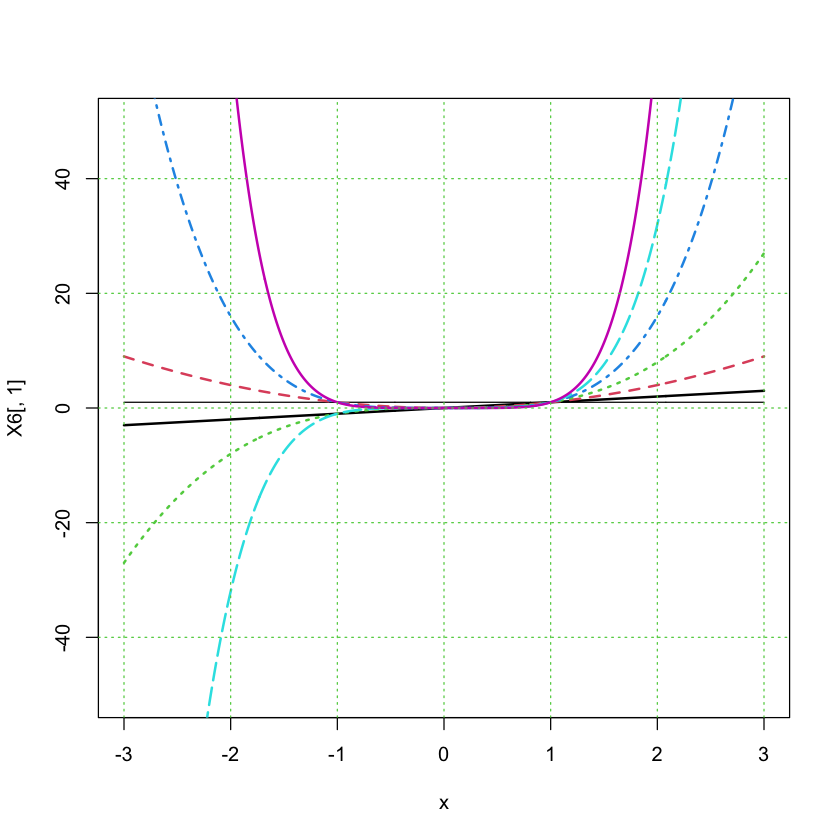

In [6]:
plot(x,X6[,1], type = 'l', ylim = c(-50,50))
matlines(x,X6[,2:7],lwd = 2)
grid(col = 3) #plotting the polynomials with degree 1,..,6

Compute also the correlation coefficients.
As you can see, even powers are correlated with each other and odd powers are also correlated with each other.


In [7]:
print(round(cor(X6[,2:7]),2))
#what can you say about the correlation?high?low? misfitting? if the features are correlated then what?==> multicollinearity ==>lead to numerical instability of fitting the model

          x I(x^2) I(x^3) I(x^4) I(x^5) I(x^6)
x      1.00   0.00   0.92   0.00   0.82   0.00
I(x^2) 0.00   1.00   0.00   0.96   0.00   0.90
I(x^3) 0.92   0.00   1.00   0.00   0.97   0.00
I(x^4) 0.00   0.96   0.00   1.00   0.00   0.98
I(x^5) 0.82   0.00   0.97   0.00   1.00   0.00
I(x^6) 0.00   0.90   0.00   0.98   0.00   1.00


By contrast, the basis function generated by poly() are not correlated at all.
They are "orthogonal polynomials".

In [8]:
print(round(cor(X6p[,2:7]),2))
#what do you notice? poly() invokes othogonal polynomials.
#donot want linear combinations of features that create other features, we want it to be othonormal basis sets ~ linear Algebra

            poly(x, 6)1 poly(x, 6)2 poly(x, 6)3 poly(x, 6)4 poly(x, 6)5
poly(x, 6)1           1           0           0           0           0
poly(x, 6)2           0           1           0           0           0
poly(x, 6)3           0           0           1           0           0
poly(x, 6)4           0           0           0           1           0
poly(x, 6)5           0           0           0           0           1
poly(x, 6)6           0           0           0           0           0
            poly(x, 6)6
poly(x, 6)1           0
poly(x, 6)2           0
poly(x, 6)3           0
poly(x, 6)4           0
poly(x, 6)5           0
poly(x, 6)6           1


The basis functions x, x^2, ... also have less desirable numerical properties.
In the matrix formulation of linear regression, the following matrix and its inverse appear:

In [9]:
A = t(X6)%*%X6 #X^TX (XtransposeX) %*% - matrix multiplication
B = solve(A) #matrix inverse

Then A*B should be the identity matrix.
Let's compute the product and check how this differs from the identity matrix:

In [10]:
max(abs(A%*%B -diag(rep(1,7)))) #this should be 0 if it is equal to the identity matrix

[1] 2.114051e-13

This should really be much smaller. However, for this particular problem, it does not cause trouble.

Now plot the orthogonal basis functions generated by poly().

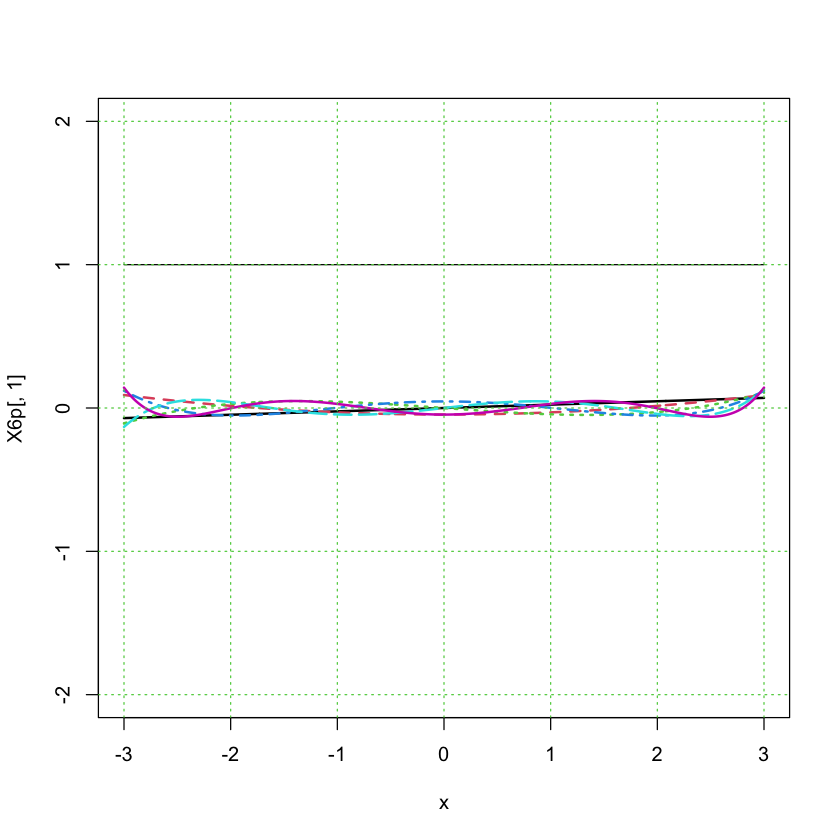

In [11]:
plot(x,X6p[,1], type = 'l', ylim = c(-2,2))
matlines(x,X6p[,2:7],lwd = 2)
grid(col = 3)

All basis functions are much more similar in magnitude.
Zoom in:

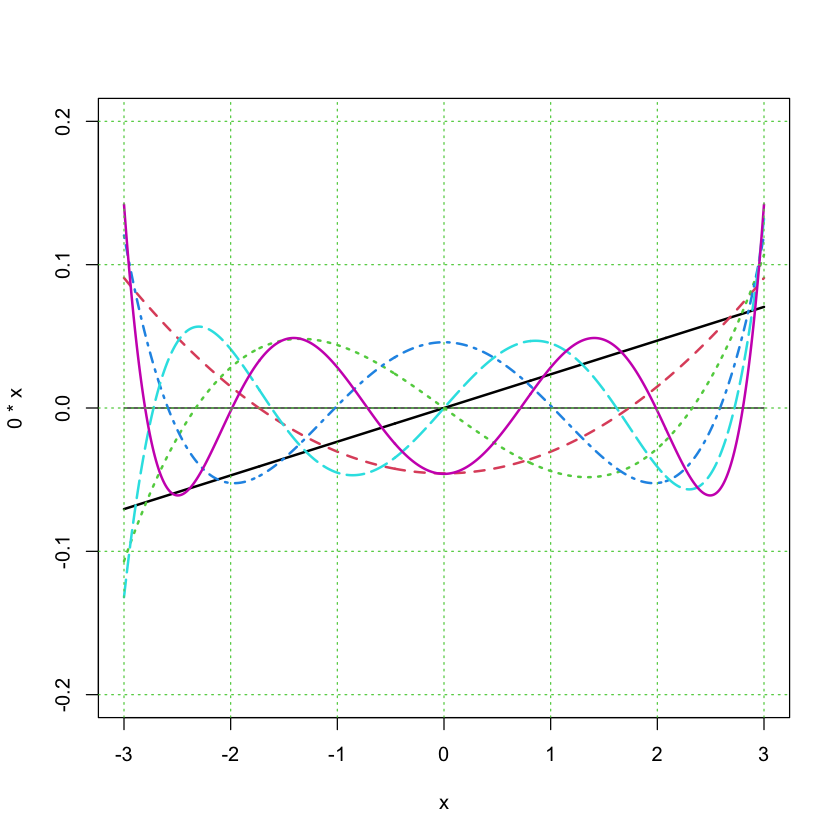

In [12]:
plot(x,0*x,ylim=c(-.2,.2), type = 'l')
matlines(x,X6p[,2:7],lwd = 2)
grid(col = 3) #6 polynomials
#othornormal basis set ==> much numerical stability for our model

These basis functions are  all uncorrelated. That is a consequence (and in fact essentially equivalent) to being orthogonal. 

In [13]:
print(round(cor(X6p[,2:7]),2))

            poly(x, 6)1 poly(x, 6)2 poly(x, 6)3 poly(x, 6)4 poly(x, 6)5
poly(x, 6)1           1           0           0           0           0
poly(x, 6)2           0           1           0           0           0
poly(x, 6)3           0           0           1           0           0
poly(x, 6)4           0           0           0           1           0
poly(x, 6)5           0           0           0           0           1
poly(x, 6)6           0           0           0           0           0
            poly(x, 6)6
poly(x, 6)1           0
poly(x, 6)2           0
poly(x, 6)3           0
poly(x, 6)4           0
poly(x, 6)5           0
poly(x, 6)6           1


Their numerical properties are also better.

In [14]:
A = t(X6p)%*%X6p
B = solve(A)
max(abs(A%*%B -diag(rep(1,7)))) #should be close to 0

[1] 5.838909e-31

In [35]:
fit=lm(y ~ poly(x,6))
print(summary(fit)) #what do you notice? Which predictors are worth keeping in the model?remeber what the data looks like? does this makes sense?


Call:
lm(formula = y ~ poly(x, 6))

Residuals:
     Min       1Q   Median       3Q      Max 
-1.42234 -0.32930  0.01873  0.31583  1.63628 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.02144    0.01976   1.085    0.278    
poly(x, 6)1   0.48500    0.48450   1.001    0.317    
poly(x, 6)2 -15.96264    0.48450 -32.947  < 2e-16 ***
poly(x, 6)3   0.14467    0.48450   0.299    0.765    
poly(x, 6)4   3.57768    0.48450   7.384 5.21e-13 ***
poly(x, 6)5  -0.08400    0.48450  -0.173    0.862    
poly(x, 6)6  -0.66912    0.48450  -1.381    0.168    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4845 on 594 degrees of freedom
Multiple R-squared:  0.658,	Adjusted R-squared:  0.6546 
F-statistic: 190.5 on 6 and 594 DF,  p-value: < 2.2e-16



### Example 1

We’ll use the Boston data set [in MASS package], for predicting the median house value (mdev), in Boston Suburbs, based on the predictor variable lstat (percentage of lower status of the population).

We’ll randomly split the data into training set (80% for building a predictive model) and test set (20% for evaluating the model). Make sure to set seed for reproducibility.

In [12]:
# Load the data
data("Boston", package = "MASS")
# Split the data into training and test set
set.seed(123)
training.samples <- Boston$medv %>%
  createDataPartition(p = 0.8, list = FALSE)
train.data  <- Boston[training.samples, ]
test.data <- Boston[-training.samples, ]

First, visualize the scatter plot of the medv vs lstat variables as follow:

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


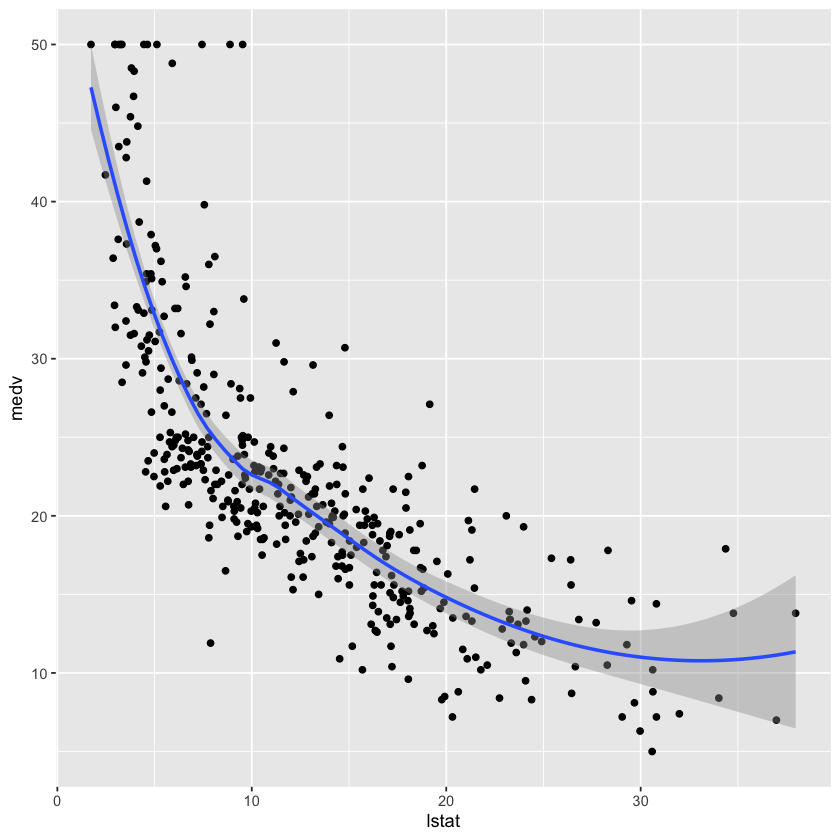

In [16]:
ggplot(train.data, aes(lstat, medv) ) +
  geom_point() +
  stat_smooth()


Let's compare the different models in order to choose the best one for our data.

The standard linear regression model equation can be written as medv = b0 + b1*lstat.

(a). Compute linear regression model:

In [17]:
# Build the model
model <- lm(medv ~ lstat, data = train.data)
# Make predictions
predictions <- model %>% predict(test.data)
# Model performance
print(data.frame(
  RMSE = RMSE(predictions, test.data$medv),
  R2 = R2(predictions, test.data$medv)
))

      RMSE       R2
1 6.503817 0.513163


Visualize the data:

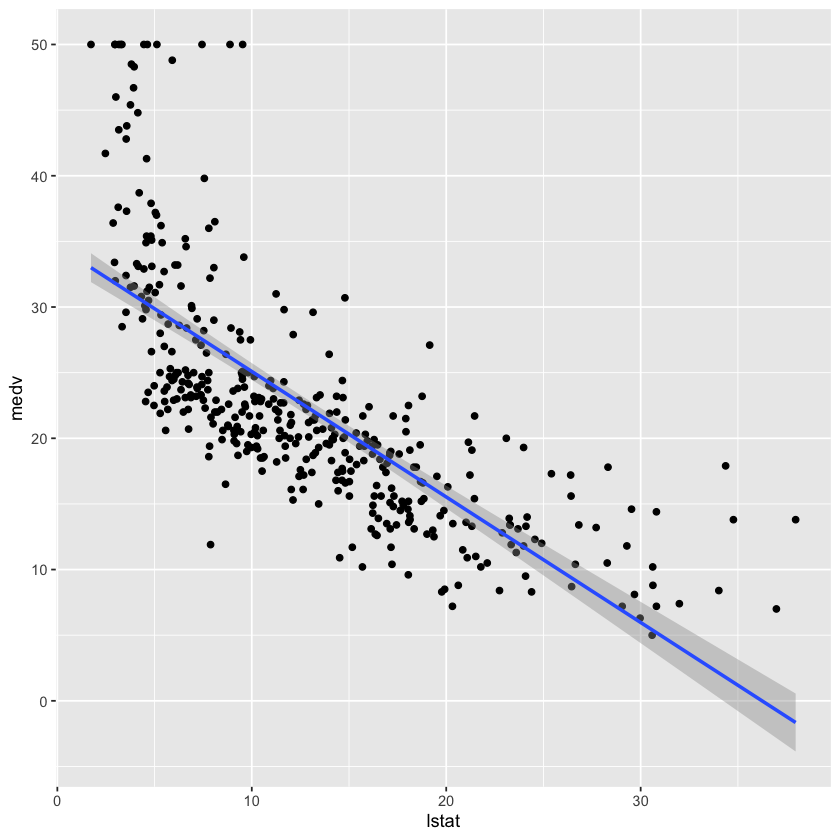

In [18]:
ggplot(train.data, aes(lstat, medv) ) +
  geom_point() +
  stat_smooth(method = lm, formula = y ~ x)

(b). Polynomial regression

The polynomial regression adds polynomial or quadratic terms to the regression equation as follow:

$medv=b0+b1*lstat+b2*lstat^2$

In R, to create a predictor x^2 you should use the function I(), as follow: I(x^2). This raise x to the power 2.


In [19]:
lm(medv ~ lstat + I(lstat^2), data = train.data)


Call:
lm(formula = medv ~ lstat + I(lstat^2), data = train.data)

Coefficients:
(Intercept)        lstat   I(lstat^2)  
    42.5736      -2.2673       0.0412  


An alternative simple solution is to use this:

In [20]:
lm(medv ~ poly(lstat, 2, raw = TRUE), data = train.data)


Call:
lm(formula = medv ~ poly(lstat, 2, raw = TRUE), data = train.data)

Coefficients:
                (Intercept)  poly(lstat, 2, raw = TRUE)1  
                    42.5736                      -2.2673  
poly(lstat, 2, raw = TRUE)2  
                     0.0412  


The output contains two coefficients associated with lstat : one for the linear term (lstat^1) and one for the quadratic term (lstat^2).

The following example computes a sixfth-order polynomial fit:

In [21]:
lm(medv ~ poly(lstat, 6, raw = TRUE), data = train.data) %>%
  summary()


Call:
lm(formula = medv ~ poly(lstat, 6, raw = TRUE), data = train.data)

Residuals:
     Min       1Q   Median       3Q      Max 
-13.1962  -3.1527  -0.7655   2.0404  26.7661 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  7.788e+01  6.844e+00  11.379  < 2e-16 ***
poly(lstat, 6, raw = TRUE)1 -1.767e+01  3.569e+00  -4.952 1.08e-06 ***
poly(lstat, 6, raw = TRUE)2  2.417e+00  6.779e-01   3.566 0.000407 ***
poly(lstat, 6, raw = TRUE)3 -1.761e-01  6.105e-02  -2.885 0.004121 ** 
poly(lstat, 6, raw = TRUE)4  6.845e-03  2.799e-03   2.446 0.014883 *  
poly(lstat, 6, raw = TRUE)5 -1.343e-04  6.290e-05  -2.136 0.033323 *  
poly(lstat, 6, raw = TRUE)6  1.047e-06  5.481e-07   1.910 0.056910 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.188 on 400 degrees of freedom
Multiple R-squared:  0.6845,	Adjusted R-squared:  0.6798 
F-statistic: 144.6 on 6 and 400 DF,  p-value: < 2.2e-16


From the output above, it can be seen that polynomial terms beyond the fith order are not significant. So, just create a fith polynomial regression model as follow:


In [22]:
# Build the model
model <- lm(medv ~ poly(lstat, 5, raw = TRUE), data = train.data)
# Make predictions
predictions <- model %>% predict(test.data)
# Model performance
print(data.frame(
  RMSE = RMSE(predictions, test.data$medv),
  R2 = R2(predictions, test.data$medv)
))

      RMSE        R2
1 5.270374 0.6829474


Visualize the fith polynomial regression line as follow:

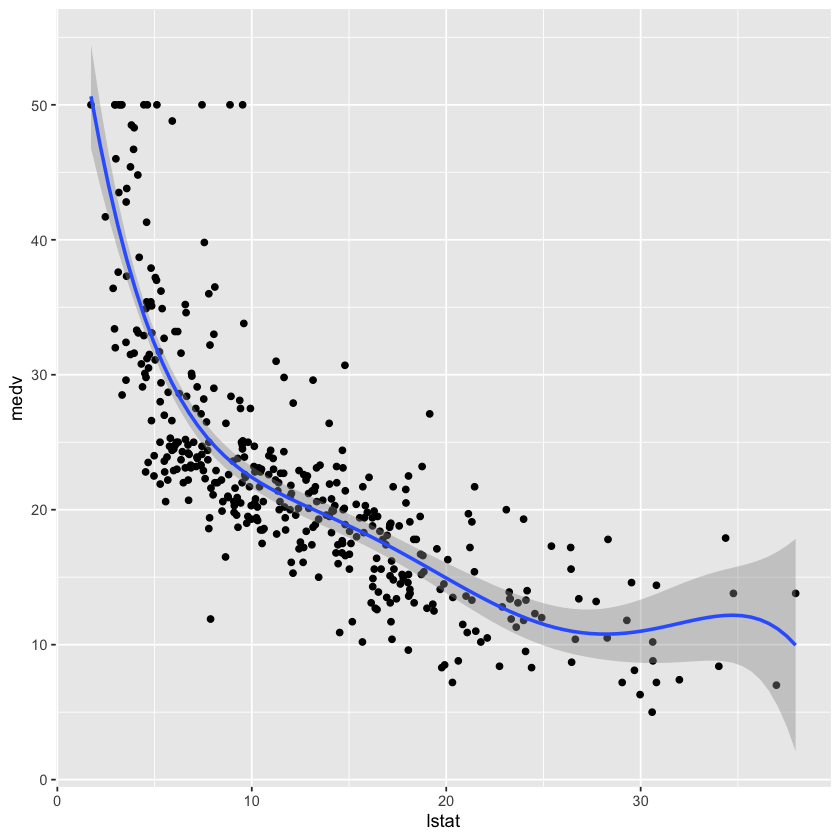

In [23]:
ggplot(train.data, aes(lstat, medv) ) +
  geom_point() +
  stat_smooth(method = lm, formula = y ~ poly(x, 5, raw = TRUE))

## Cubic Splines and Smoothing Splines

Cubic spline with fixed knots.


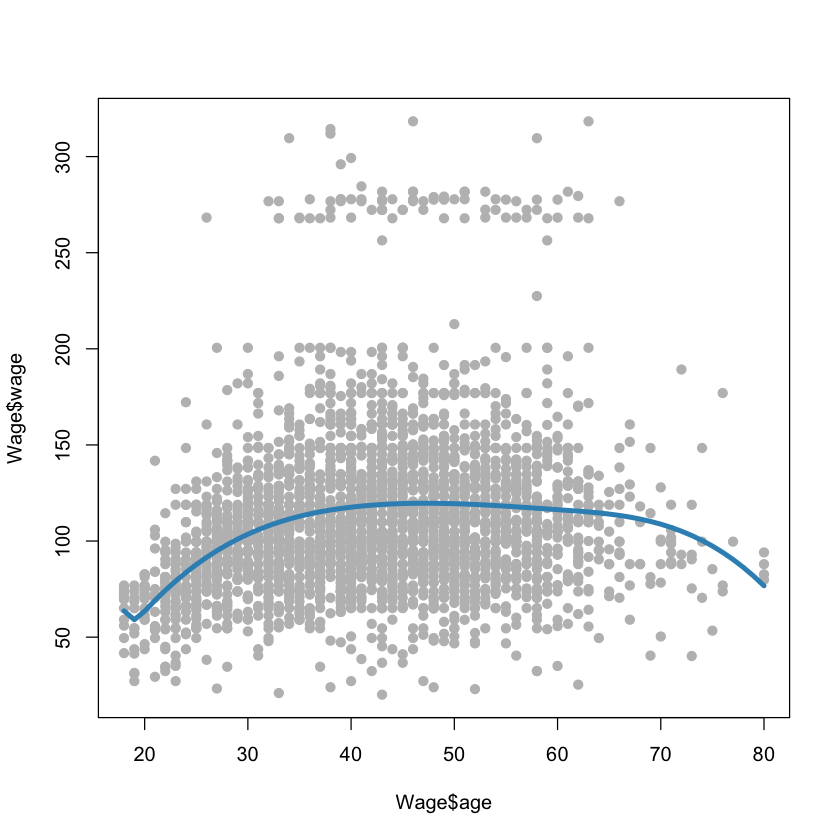

In [ ]:
#library(splineDesign)
attach(Wage)
agelims=range(Wage$age)
age.grid=seq(from=agelims[1],to=agelims[2])
spline_fit <- lm(wage ~ bs(age, knots=c(20,40,60)), data=Wage)

plot(Wage$age, Wage$wage, pch=19, col='grey')
pred = predict(spline_fit,list(age=age.grid), se=T)
lines(age.grid,pred$fit, col="#3690C0",lwd=4)

A natural spline has better behavior at the boundary points.

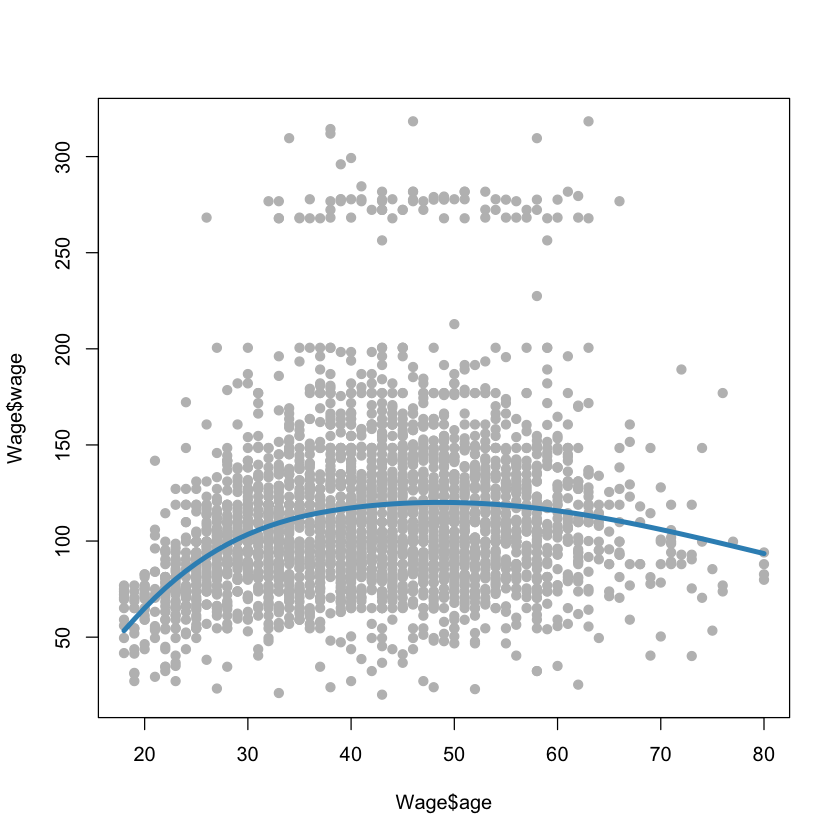

In [25]:
agelims=range(Wage$age)
age.grid=seq(from=agelims[1],to=agelims[2])

spline_fit <- lm(wage ~ ns(age, knots=c(20,40,60)), data=Wage)
plot(Wage$age, Wage$wage, pch=19, col='grey')
pred = predict(spline_fit,list(age=age.grid), se=T)
lines(age.grid,pred$fit, col="#3690C0",lwd=4)

A smoothing spline is a cubic spline with a knot at every observed $x$ but also a penalization to encourage smoothness.

Warning message in smooth.spline(Wage$age, Wage$wage, cv = TRUE):
“cross-validation with non-unique 'x' values seems doubtful”


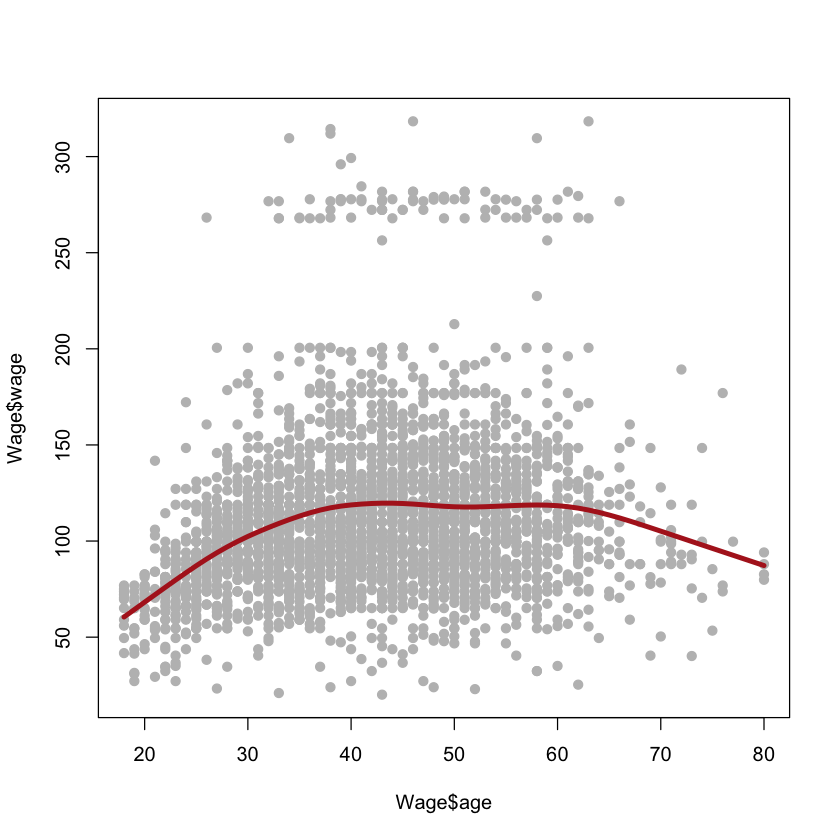

In [ ]:
plot(Wage$age, Wage$wage, pch=19, col='grey')
ss_fit <- smooth.spline(Wage$age,Wage$wage,cv=TRUE)
lines(ss_fit,col="firebrick", lwd=4)

### Example 2

For our previous example, we’ll place the knots at the lower quartile, the median quartile, and the upper quartile:

In [27]:
knots <- quantile(train.data$lstat, p = c(0.25, 0.5, 0.75))


We’ll create a model using a cubic spline (degree = 3):


In [28]:
# Build the model
knots <- quantile(train.data$lstat, p = c(0.25, 0.5, 0.75))
model <- lm (medv ~ bs(lstat, knots = knots), data = train.data)
# Make predictions
predictions <- model %>% predict(test.data)
# Model performance
print(data.frame(
  RMSE = RMSE(predictions, test.data$medv),
  R2 = R2(predictions, test.data$medv)
))


      RMSE        R2
1 5.317372 0.6786367


Note that, the coefficients for a spline term are not interpretable.

Visualize the cubic spline as follow:

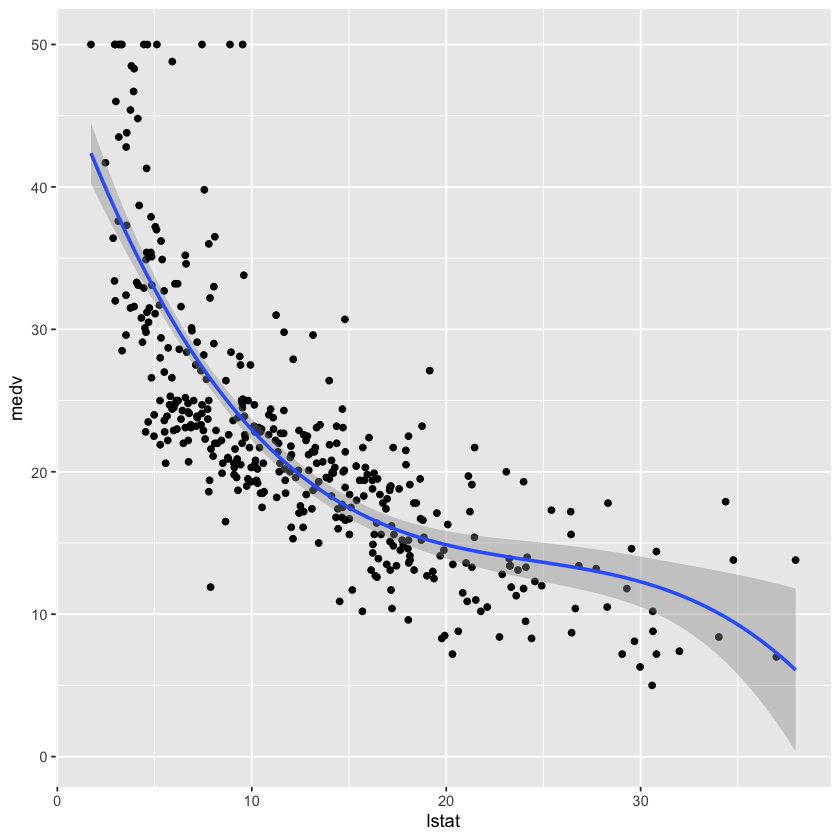

In [29]:
ggplot(train.data, aes(lstat, medv) ) +
  geom_point() +
  stat_smooth(method = lm, formula = y ~ splines::bs(x, df = 3))

## GAM 


In [13]:
# Build the model
model <- gam(medv ~ s(lstat), data = train.data)
# Make predictions
predictions <- model %>% predict(test.data)
# Model performance
print(data.frame(
  RMSE = RMSE(predictions, test.data$medv),
  R2 = R2(predictions, test.data$medv)
))

     RMSE        R2
1 5.42684 0.6610243


Warning message in newdata.predict.Gam(object, newdata, type, dispersion, se.fit, :
“No standard errors (currently) for gam predictions with newdata”
Warning message:
“Failed to fit group -1.
Caused by error in `pred$fit`:
! $ operator is invalid for atomic vectors”


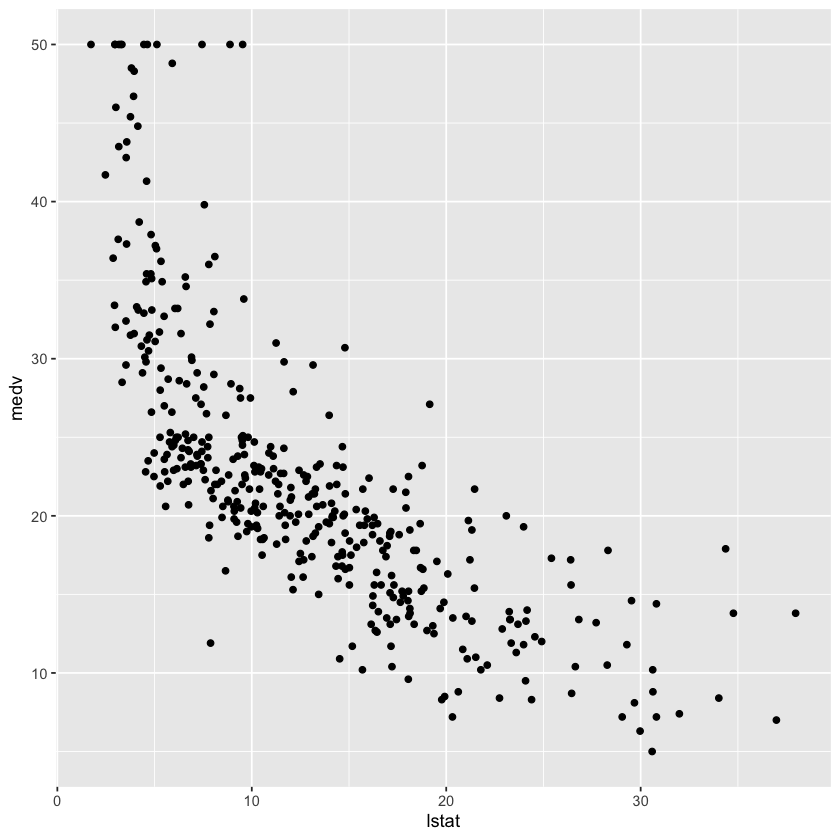

In [31]:
ggplot(train.data, aes(lstat, medv) ) +
  geom_point() +
  stat_smooth(method = gam, formula = y ~ s(x))

From analyzing the RMSE and the R2 metrics of the different models, it can be seen that the polynomial regression, the spline regression and the generalized additive models outperform the linear regression model and the log transformation approaches.

### From the book



In [33]:
print(wage~ns(year,4))

wage ~ ns(year, 4)


In [34]:
print(class(Wage$education))

[1] "factor"



Call: gam(formula = wage ~ s(year, 4) + s(age, 5) + education, data = Wage)
Deviance Residuals:
    Min      1Q  Median      3Q     Max 
-119.43  -19.70   -3.33   14.17  213.48 

(Dispersion Parameter for gaussian family taken to be 1235.69)

    Null Deviance: 5222086 on 2999 degrees of freedom
Residual Deviance: 3689770 on 2986 degrees of freedom
AIC: 29887.75 

Number of Local Scoring Iterations: NA 

Anova for Parametric Effects
             Df  Sum Sq Mean Sq F value    Pr(>F)    
s(year, 4)    1   27162   27162  21.981 2.877e-06 ***
s(age, 5)     1  195338  195338 158.081 < 2.2e-16 ***
education     4 1069726  267432 216.423 < 2.2e-16 ***
Residuals  2986 3689770    1236                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Anova for Nonparametric Effects
            Npar Df Npar F  Pr(F)    
(Intercept)                          
s(year, 4)        3  1.086 0.3537    
s(age, 5)         4 32.380 <2e-16 ***
education                            
--

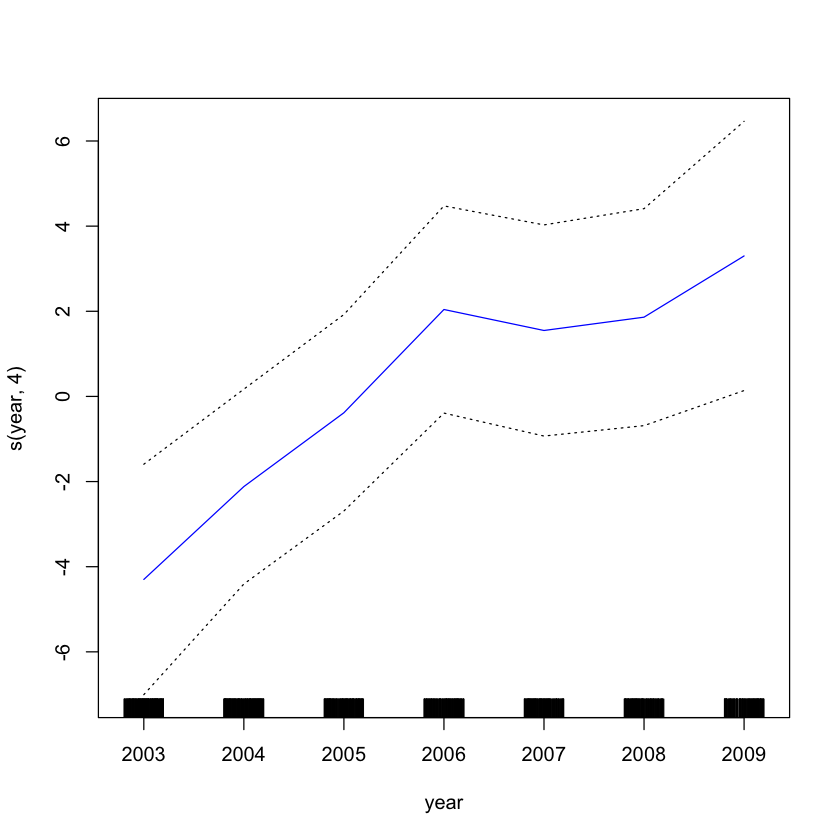

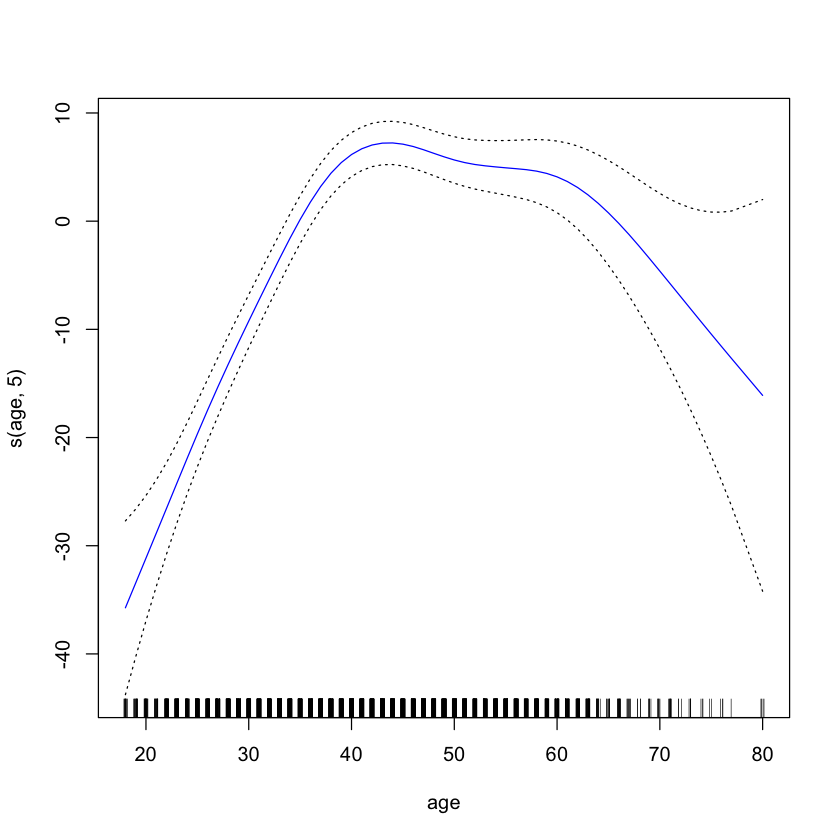

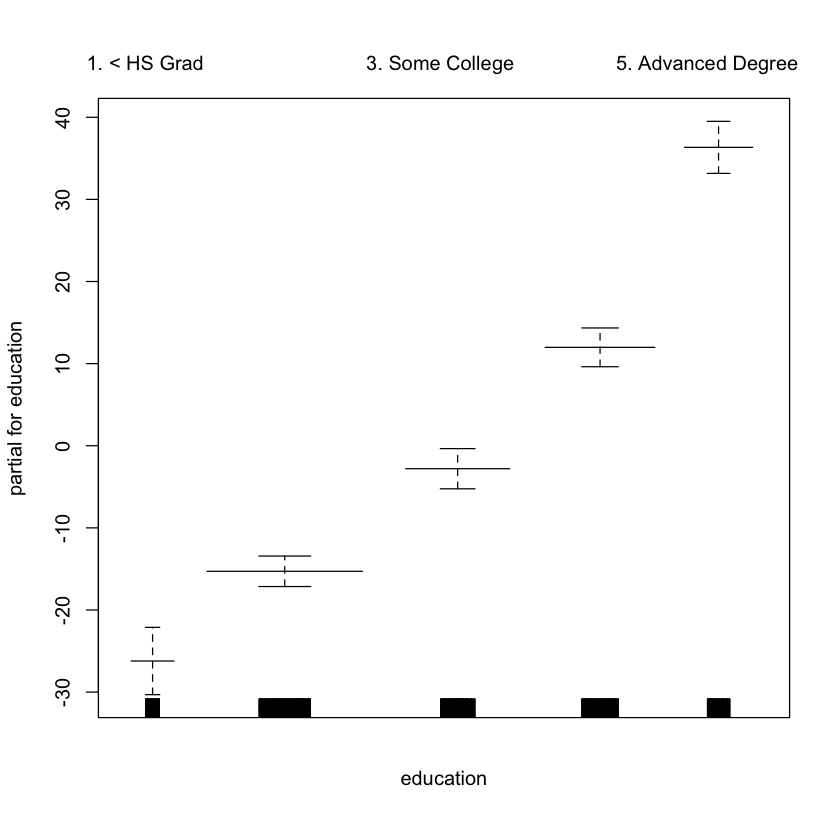

In [35]:
gam1=lm(wage~ns(year,4)+ns(age,5)+education,data=Wage)
gam.m3=gam(wage~s(year,4)+s(age,5)+education,data=Wage)

summary(gam.m3)

plot(gam.m3, se=TRUE,col="blue")

Analysis of Deviance Table

Model 1: wage ~ s(age, 5) + education
Model 2: wage ~ year + s(age, 5) + education
Model 3: wage ~ s(year, 4) + s(age, 5) + education
  Resid. Df Resid. Dev Df Deviance       F    Pr(>F)    
1      2990    3711731                                  
2      2989    3693842  1  17889.2 14.4771 0.0001447 ***
3      2986    3689770  3   4071.1  1.0982 0.3485661    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


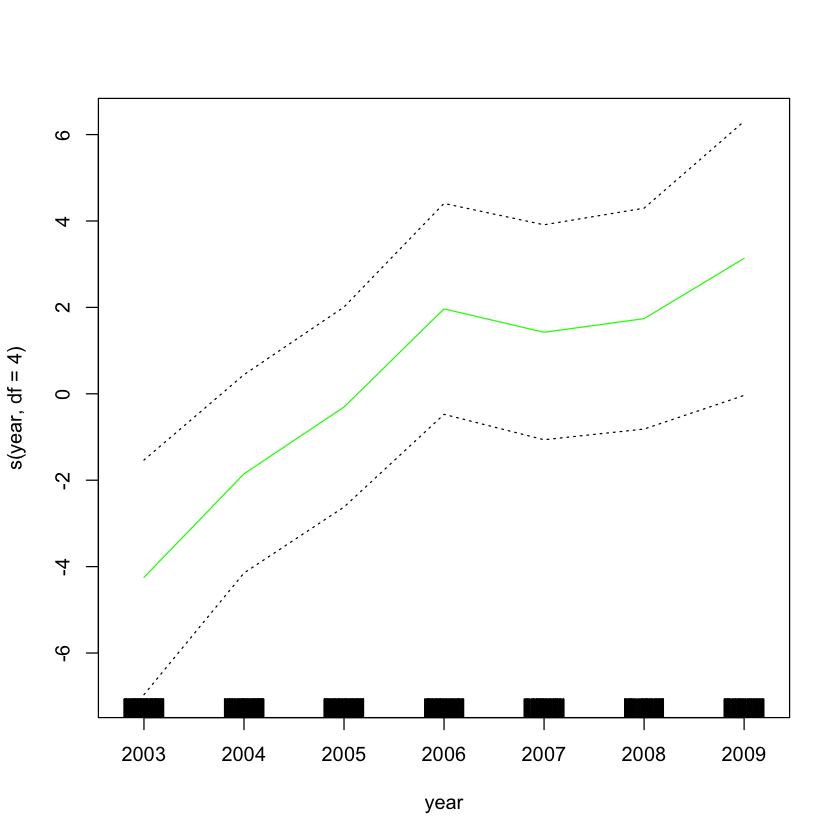

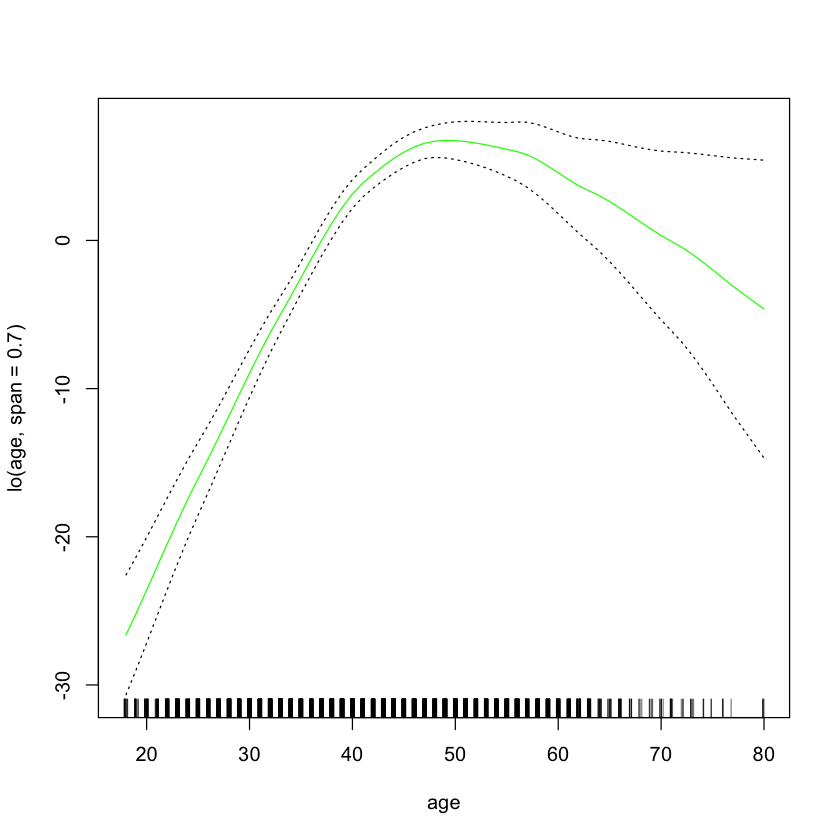

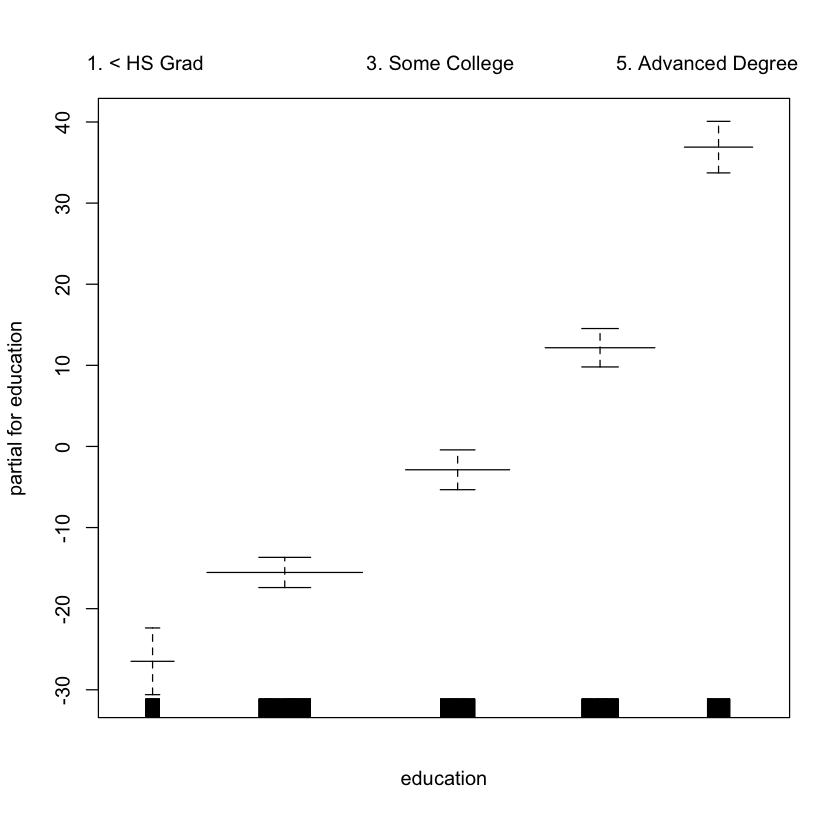

In [36]:
gam.m1=gam(wage~s(age,5)+education,data=Wage)
gam.m2=gam(wage~year+s(age,5)+education,data=Wage)
gam.m3=gam(wage~s(year,4)+s(age,5)+education,data=Wage)
print(anova(gam.m1,gam.m2,gam.m3,test="F"))

preds=predict(gam.m2,newdata=Wage)

gam.lo=gam(wage~s(year,df=4)+lo(age,span=0.7)+education,data=Wage)
plot(gam.lo, se=TRUE, col="green")

## LOESS

In [38]:
# install.packages('dslabs')


The downloaded binary packages are in
	/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T//RtmpvTPIAP/downloaded_packages


Warning message:
“package ‘dslabs’ was built under R version 4.5.2”
Warning message:
“`qplot()` was deprecated in ggplot2 3.4.0.”


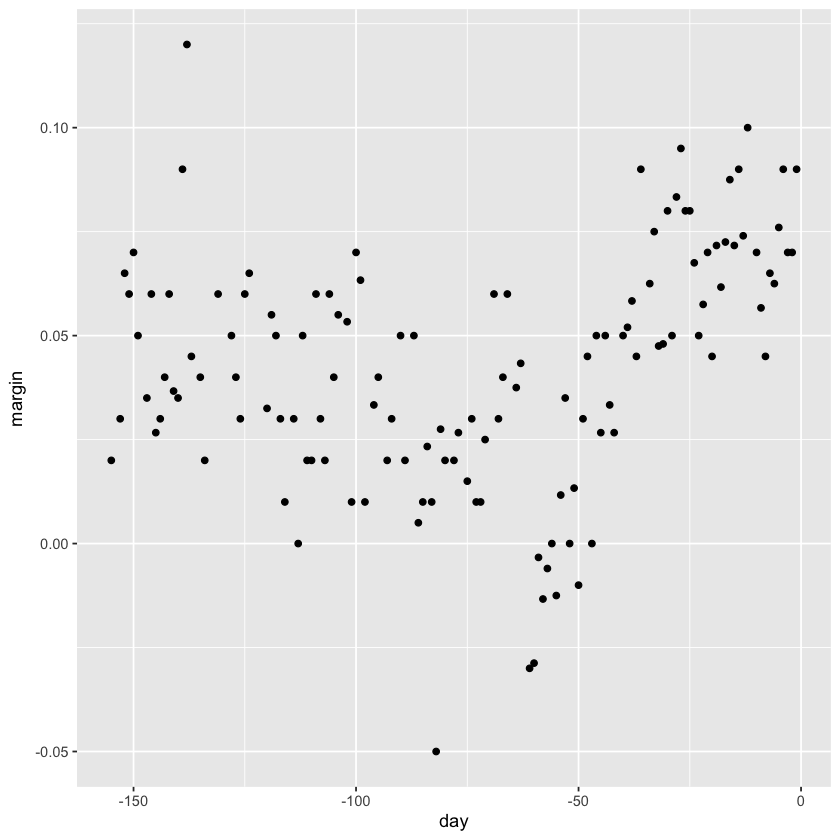

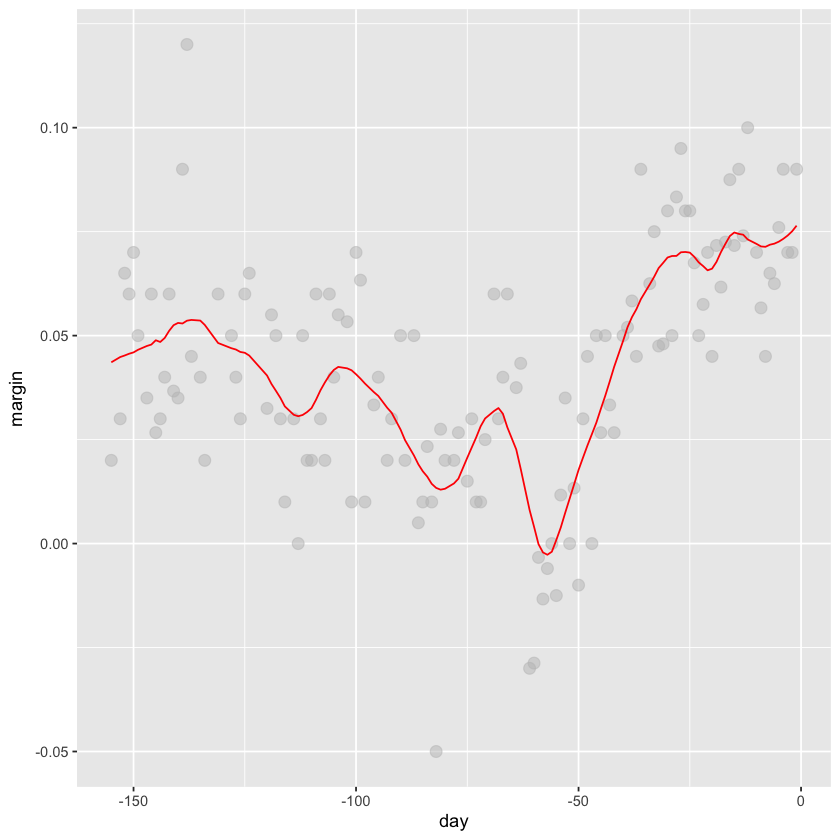

In [39]:
library(tidyverse)
library(dslabs)
library(caret)

data("polls_2008")
qplot(day, margin, data = polls_2008)

total_days <- diff(range(polls_2008$day))
span <- 21/total_days

fit <- loess(margin ~ day, degree=1, span = span, data=polls_2008)

polls_2008 %>% mutate(smooth = fit$fitted) %>%
  ggplot(aes(day, margin)) +
  geom_point(size = 3, alpha = .5, color = "grey") +
  geom_line(aes(day, smooth), color="red")

### From the book

The following objects are masked from Wage (pos = 4):

    age, education, health, health_ins, jobclass, logwage, maritl,
    race, region, wage, year




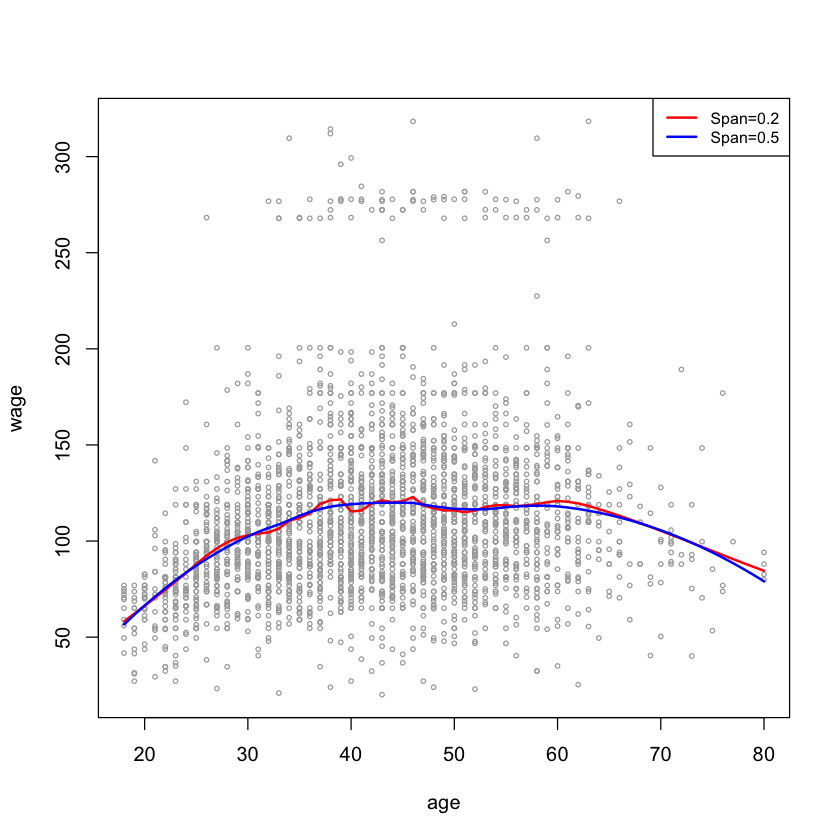

In [40]:
attach(Wage)
plot(age,wage,xlim=agelims ,cex=.5,col="darkgrey")
fit=loess(wage~age,span=.2,data=Wage)
fit2=loess(wage~age,span=.5,data=Wage)
lines(age.grid,predict(fit,data.frame(age=age.grid)),col="red",lwd=2)
lines(age.grid,predict(fit2,data.frame(age=age.grid)),col="blue",lwd=2)
legend("topright",legend=c("Span=0.2","Span=0.5"),col=c("red","blue"),lty=1,lwd=2,cex=.8)

# Part-2: Lab-Assignment


## Question-1: 

Please write a paragraph about what you can conclude from this example (i.e. final Conclusions).  

### S&P Data: Discuss this with your group members 

We will working with the weekly S&P500 data.

In [41]:
print(names(Weekly))
print(head(Weekly))
attach(Weekly) #time series data

[1] "Year"      "Lag1"      "Lag2"      "Lag3"      "Lag4"      "Lag5"     
[7] "Volume"    "Today"     "Direction"
  Year   Lag1   Lag2   Lag3   Lag4   Lag5    Volume  Today Direction
1 1990  0.816  1.572 -3.936 -0.229 -3.484 0.1549760 -0.270      Down
2 1990 -0.270  0.816  1.572 -3.936 -0.229 0.1485740 -2.576      Down
3 1990 -2.576 -0.270  0.816  1.572 -3.936 0.1598375  3.514        Up
4 1990  3.514 -2.576 -0.270  0.816  1.572 0.1616300  0.712        Up
5 1990  0.712  3.514 -2.576 -0.270  0.816 0.1537280  1.178        Up
6 1990  1.178  0.712  3.514 -2.576 -0.270 0.1544440 -1.372      Down


We want to predict weekly Volume from performance in previous weeks. 

Make an additive model that uses polynomial regression for each of the predictors.


Call: gam(formula = Volume ~ poly(Lag1, 3) + poly(Lag2, 3) + poly(Lag3, 
    3))
Deviance Residuals:
    Min      1Q  Median      3Q     Max 
-3.5228 -1.0298 -0.6724  0.6498  7.8760 

(Dispersion Parameter for gaussian family taken to be 2.4057)

    Null Deviance: 3095.08 on 1088 degrees of freedom
Residual Deviance: 2595.744 on 1079 degrees of freedom
AIC: 4058.368 

Number of Local Scoring Iterations: 2 

Anova for Parametric Effects
                Df  Sum Sq Mean Sq F value    Pr(>F)    
poly(Lag1, 3)    3  275.25  91.749  38.139 < 2.2e-16 ***
poly(Lag2, 3)    3  132.33  44.109  18.335 1.317e-11 ***
poly(Lag3, 3)    3   91.76  30.587  12.714 3.604e-08 ***
Residuals     1079 2595.74   2.406                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


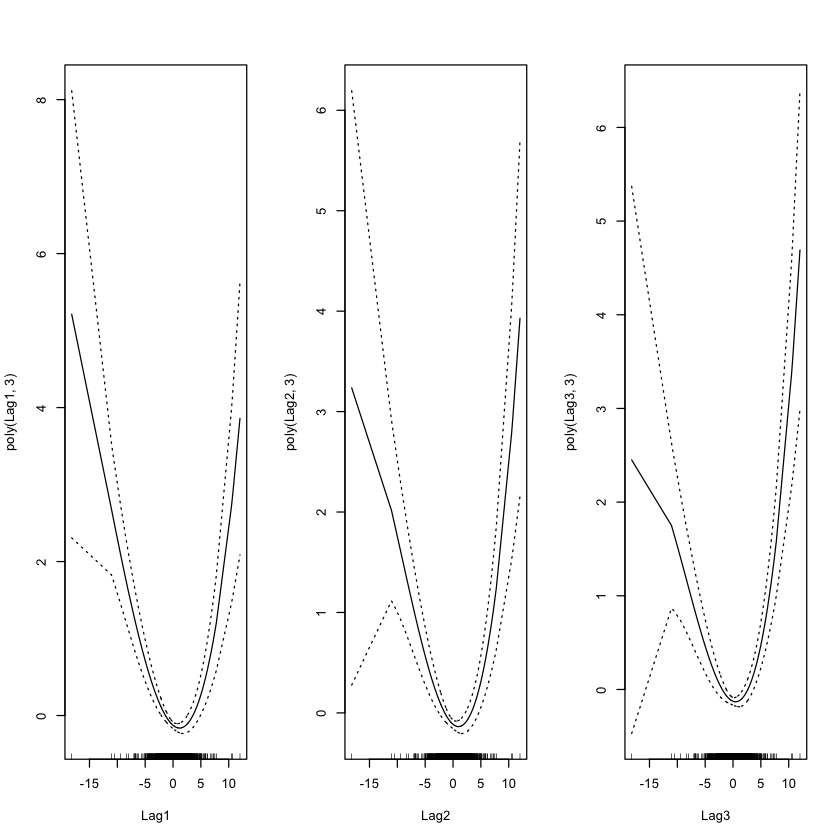

In [42]:
library(gam)
fit4 = gam(Volume ~ poly(Lag1,3 ) + poly(Lag2,3 ) + poly(Lag3,3 )) #polynomials of lag features
summary(fit4)
par(mfrow=c(1,3)) #to partition the Plotting Window
plot(fit4,se = TRUE)

Plot the data and the fits. 

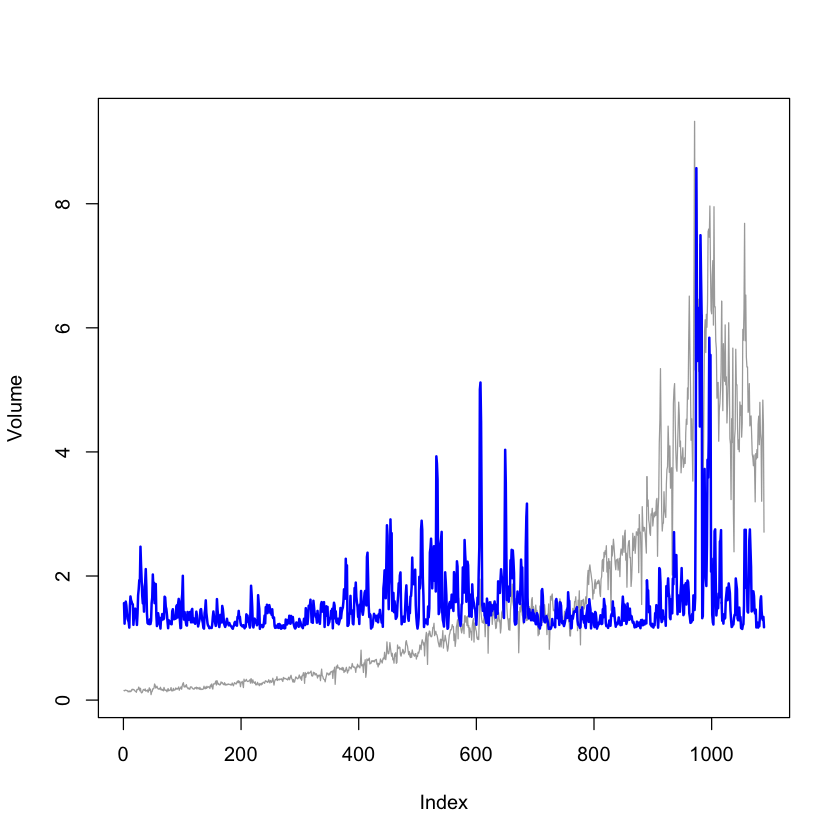

In [43]:
plot(Volume,col="darkgrey",type="l")
preds.Weekly=predict(fit4,se=TRUE)
lines(preds.Weekly$fit,lwd=2,col="blue") #need to treat this as time series data

Clearly the fits have nothing to do with the data. It is essential to include time in the fit. Also, the exponential increase of the trading volume suggests that one should look at the log of the volume.


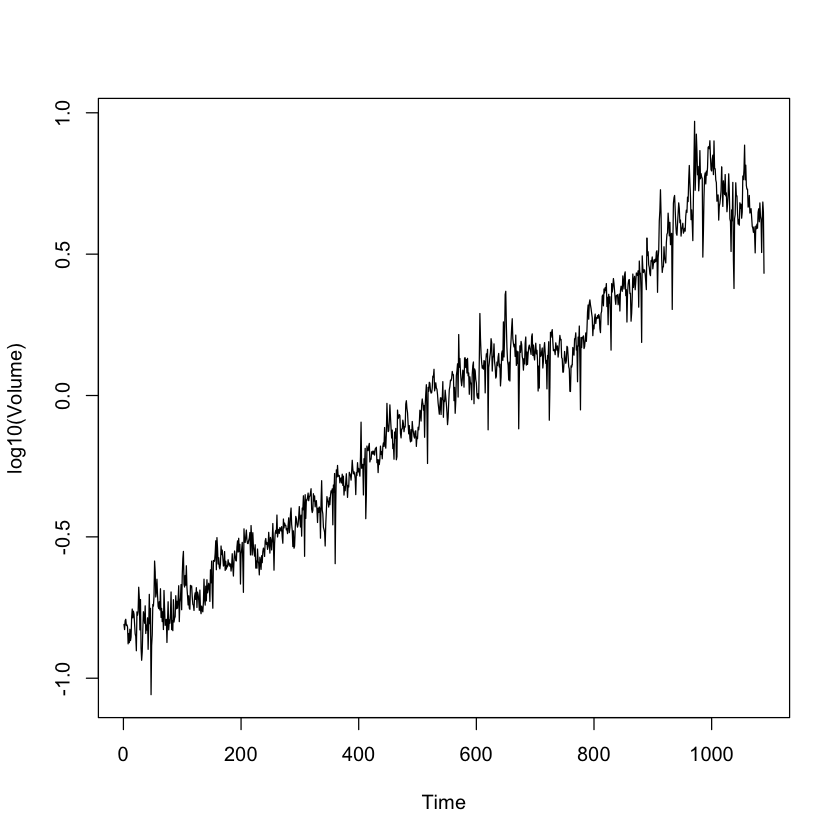

In [44]:
plot.ts(log10(Volume), type="l")

There is a general linear trend, the magnitude of the variation is about the same for all years, there are deviations from the linear trend around the years 2002 and 2008, and there may be seasonal variation. 


### Smoothing splines

 We can use smoothing splines to summarize these data. For very large penalty parameters $\lambda$ or equivalently $df = 2$, a smoothing spline is essentially a straight line. We'll make such a smoothing spline, compute predictions, and plot it. Choosing a large lambda is equivalent to using two degrees of freedom (two parameters are fitted).


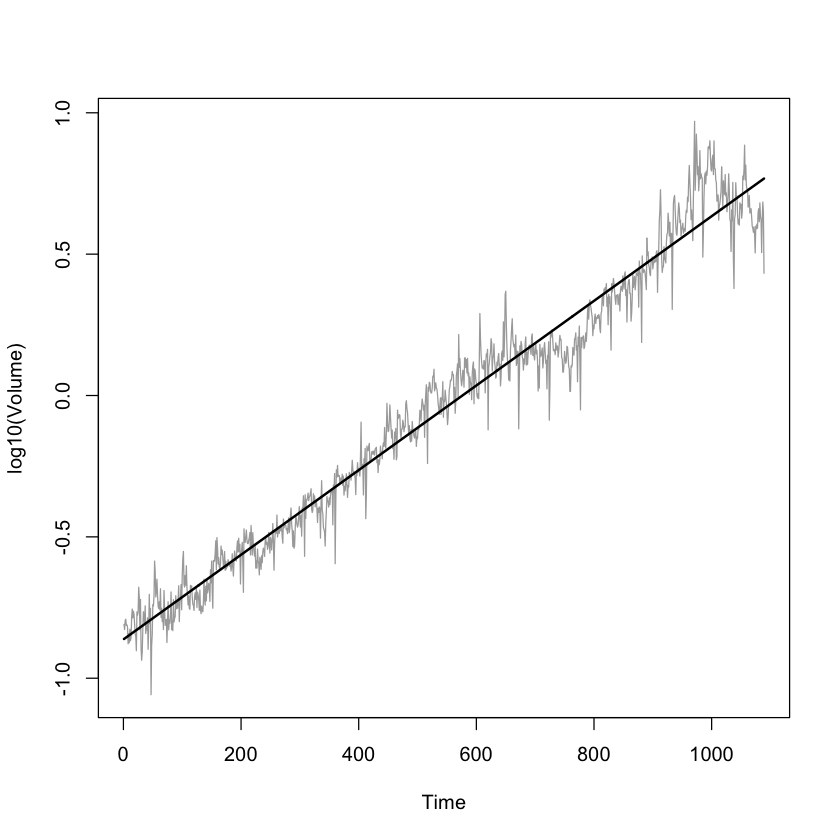

In [45]:
fit.s1 = smooth.spline(log10(Volume) ~  1:1089, df = 2) #constraint or flexible with df=2? linear?
preds.s1 = predict(fit.s1)
plot.ts(log10(Volume), col = "darkgrey")
lines(preds.s1$y, lwd =2 ) #high bias?low bias?

To capture year-to-year variation, increase the number of degrees of freedom. Let's use one df per year, plus one for the intercept. This is plotted in red.

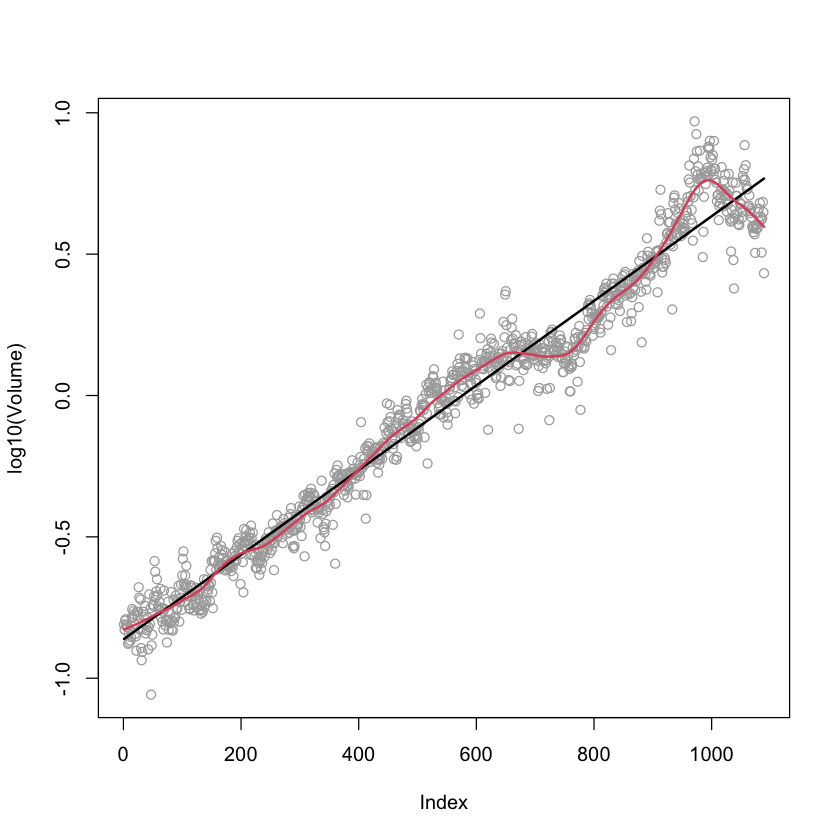

In [46]:
fit.s1 = smooth.spline(log10(Volume) ~  1:1089, df = 2)
preds.s1 = predict(fit.s1)
fit.s22 = smooth.spline(log10(Volume) ~  1:1089, df = 22)
preds.s22 = predict(fit.s22)

plot(log10(Volume), col = "darkgrey")
lines(preds.s1$y, lwd =2 )
lines(preds.s22$y, lwd =2, col = 2)

To capture also seasonal variation, increase the number of degrees of freedom further. We use four df per year, plus one for the intercept. This is plotted in blue.

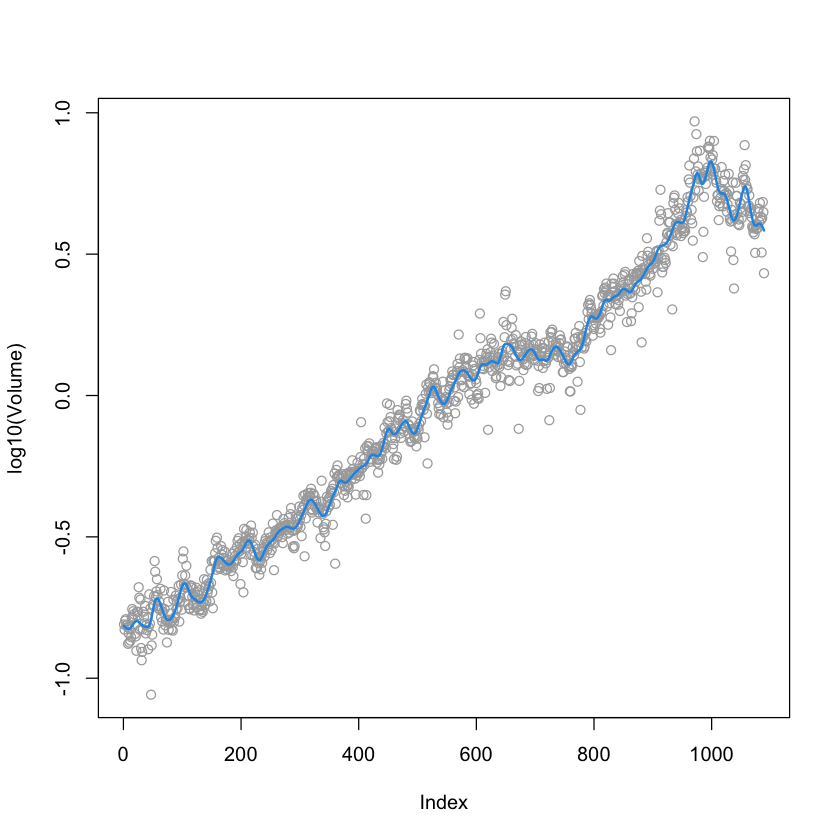

In [47]:
fit.s85 = smooth.spline(log10(Volume) ~  1:1089, df = 85)
preds.s85 = predict(fit.s85)

plot(log10(Volume), col = "darkgrey")
lines(preds.s85$y, lwd =2, col = 4) #what can you say about the overall market trend?

When the number of degrees of freedom is not specified, \texttt{gam} chooses one. Here is the resulting plot. This fit uses about 120 degrees of freedom.

Call:
smooth.spline(x = log10(Volume) ~ 1:1089)

Smoothing Parameter  spar= 0.1833952  lambda= 3.62849e-08 (12 iterations)
Equivalent Degrees of Freedom (Df): 120.1739
Penalized Criterion (RSS): 2.895513
GCV: 0.0033594

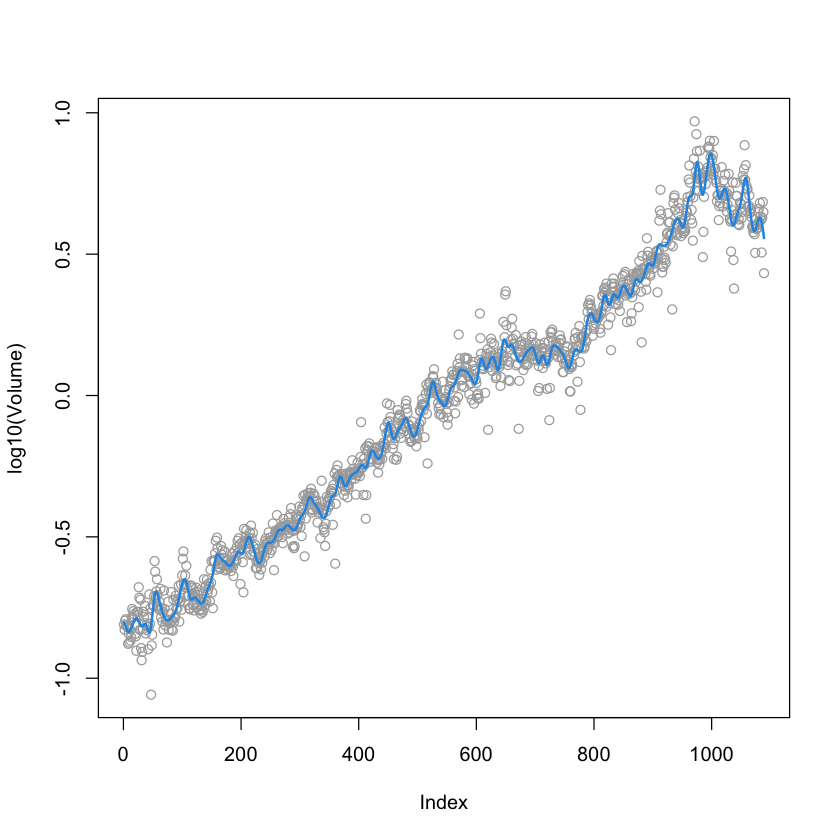

In [48]:
fit.s = smooth.spline(log10(Volume) ~  1:1089)
preds.s = predict(fit.s)

plot(log10(Volume), col = "darkgrey")
lines(preds.s$y, lwd =2, col = 4)
fit.s

### Solution: 

INSERT FINAL CONCLUSIONS HERE

## Question-2

This question relates to the College data set.

(a) Split the data into a training set and a test set. Using out-of-state tuition as the response and the other variables as the predictors, perform forward stepwise selection on the training set in order to identify a satisfactory model that uses just a subset of the predictors. Plot the BIC to pick the best model (cross validation could also be used).


In [6]:
install.packages("leaps")


The downloaded binary packages are in
	/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T//RtmpjZQaZ2/downloaded_packages


In [2]:
library(leaps)
library(ISLR)
data("College")
head(College)

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
Albertson College,Yes,587,479,158,38,62,678,41,13500,3335,500,675,67,73,9.4,11,9727,55


Use training set to fit full model with all variables and find the optimal model size according to BIC, RSS and R-adj squared.

In [5]:
# split data into train and test
set.seed(1)
# generate a random sample of logical values (TRUE or FALSE)
train=sample(c(TRUE,FALSE), nrow(College),rep=TRUE)
test=(!train)

In [10]:
# fit a full model with all variables as predictors on training set
regfit.fwd=regsubsets(Outstate~.,data=College[train,],nvmax=17,method="forward")

In [11]:
# print model summary
reg.summary = summary(regfit.fwd)
print(reg.summary)

Subset selection object
Call: regsubsets.formula(Outstate ~ ., data = College[train, ], nvmax = 17, 
    method = "forward")
17 Variables  (and intercept)
            Forced in Forced out
PrivateYes      FALSE      FALSE
Apps            FALSE      FALSE
Accept          FALSE      FALSE
Enroll          FALSE      FALSE
Top10perc       FALSE      FALSE
Top25perc       FALSE      FALSE
F.Undergrad     FALSE      FALSE
P.Undergrad     FALSE      FALSE
Room.Board      FALSE      FALSE
Books           FALSE      FALSE
Personal        FALSE      FALSE
PhD             FALSE      FALSE
Terminal        FALSE      FALSE
S.F.Ratio       FALSE      FALSE
perc.alumni     FALSE      FALSE
Expend          FALSE      FALSE
Grad.Rate       FALSE      FALSE
1 subsets of each size up to 17
Selection Algorithm: forward
          PrivateYes Apps Accept Enroll Top10perc Top25perc F.Undergrad
1  ( 1 )  " "        " "  " "    " "    " "       " "       " "        
2  ( 1 )  "*"        " "  " "    " "    " "   

[1] "optimal feature subset-size according to adjr2:"
[2] "13"                                             


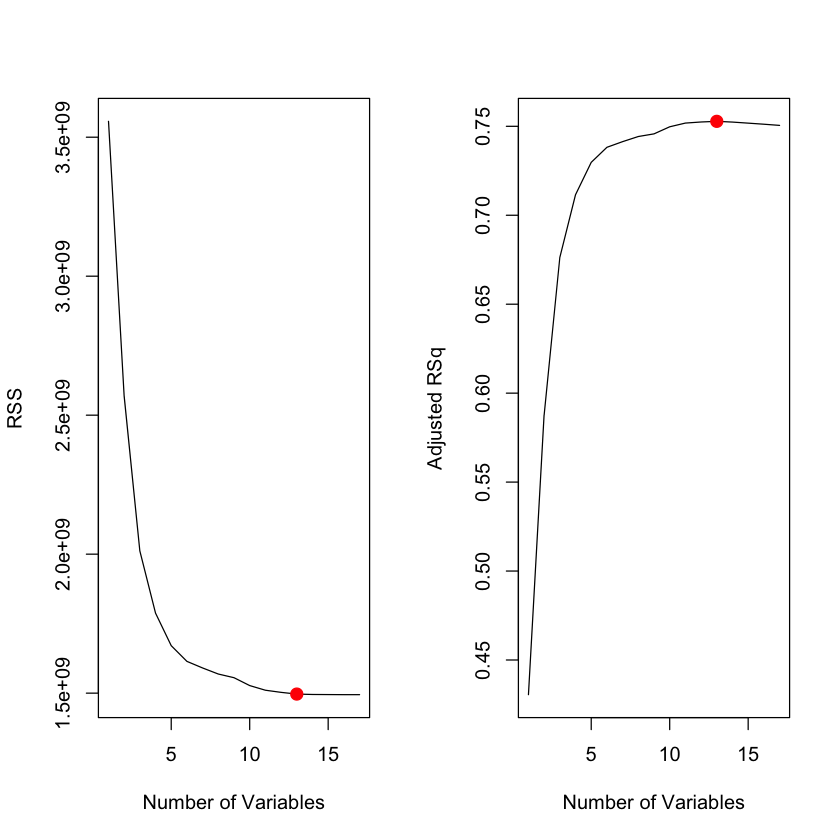

In [12]:
# plot adjr2 by model subset size to determine the optimal feature subset size
par(mfrow=c(1,2))

# get the index (m) of the maximum adjusted R-squared value
m=which.max(reg.summary$adjr2);
print(c("optimal feature subset-size according to adjr2:",m))

# plot rss against the number of variables
plot(reg.summary$rss,xlab="Number of Variables",ylab="RSS",type="l")
points(m,reg.summary$rss[m], col="red",cex=2,pch=20)

# plot adj-r2 against the number of variables
plot(reg.summary$adjr2,xlab="Number of Variables",ylab="Adjusted RSq",type="l")
points(m,reg.summary$adjr2[m], col="red",cex=2,pch=20)

[1] "optimal feature subset-size according to BIC:"
[2] "6"                                            


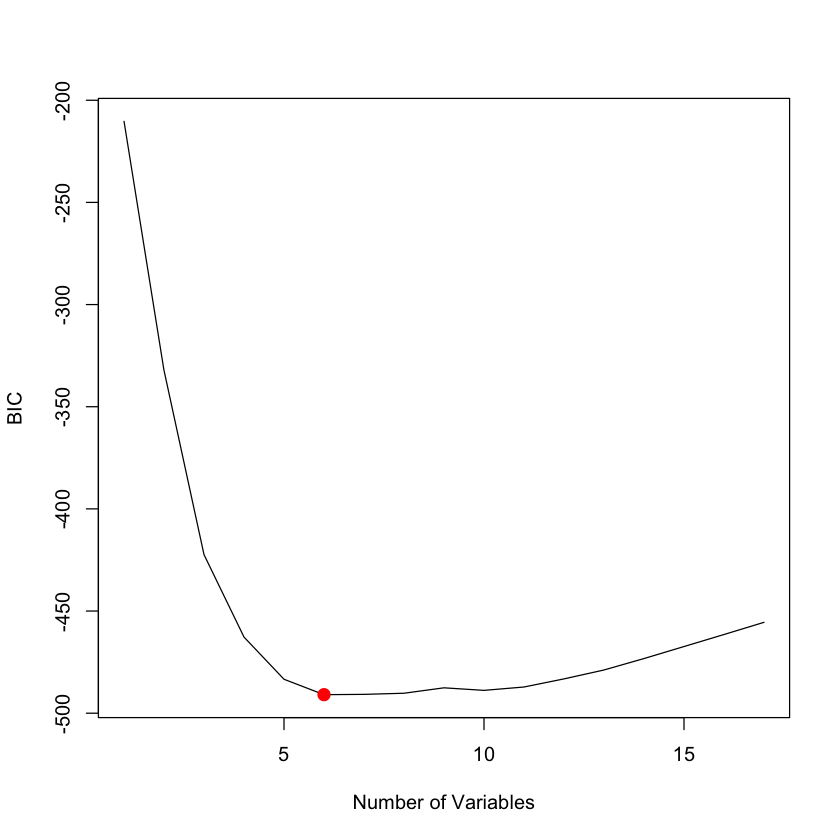

In [13]:
# plot the feature subset size by BIC
m=which.min(reg.summary$bic) # subset with lowest BIC
print(c("optimal feature subset-size according to BIC:",m))
plot(reg.summary$bic,xlab="Number of Variables",ylab="BIC",type='l')
points(m,reg.summary$bic[6],col="red",cex=2,pch=20)

Use 10-fold cross validation to find the subset with lowest validation error

In [14]:
# Set the number of folds for cross-validation
k = 10

# Set the seed for reproducibility
set.seed(1)

# Create k-fold subsets of observations
folds = sample(1:k, nrow(College), replace = TRUE)

# Create matrices to store cross-validation errors for each model
cv.errors = matrix(NA, k, 17, dimnames = list(NULL, paste(1:17)))

In [ ]:
predict.regsubsets = function(object, newdata, id, ...) {
  # extract formula
  form = as.formula(object$call[[2]])

  # build model matrix for new data
  mat = model.matrix(form, newdata)

  # extract coefficients for model size 'id'
  coefi = coef(object, id = id)

  # find which variables are in the model
  xvars = names(coefi)

  # compute predictions
  mat[, xvars] %*% coefi
}

In [18]:
# loop over each fold for cross-validation
for (j in 1:k) {
  # fit regression models using subsets of predictors
  # leave out the 'j-th' fold for validation
  regfit.fwd = regsubsets(Outstate ~ ., data = College[folds != j, ], nvmax = 17, method='forward')
  # generate summary of model results
  reg.summary = summary(regfit.fwd)

  # loop over each subset size (1 to 17)
  for (i in 1:17) {
    # make predictions using the 'i-th' subset from the 'regfit.fwd' model
    pred = predict(regfit.fwd, College[folds == j, ], id = i)

    # calculate the mean squared error for the current fold and subset
    cv.errors[j, i] = mean((College$Outstate[folds == j] - pred)^2)
  }
}

      1       2       3       4       5       6       7       8       9      10 
8951783 6481587 5263274 4678635 4470280 4278580 4308291 4304902 4213389 4294562 
     11      12      13      14      15      16      17 
4155205 4144059 4089216 4089766 4083477 4074634 4074807 


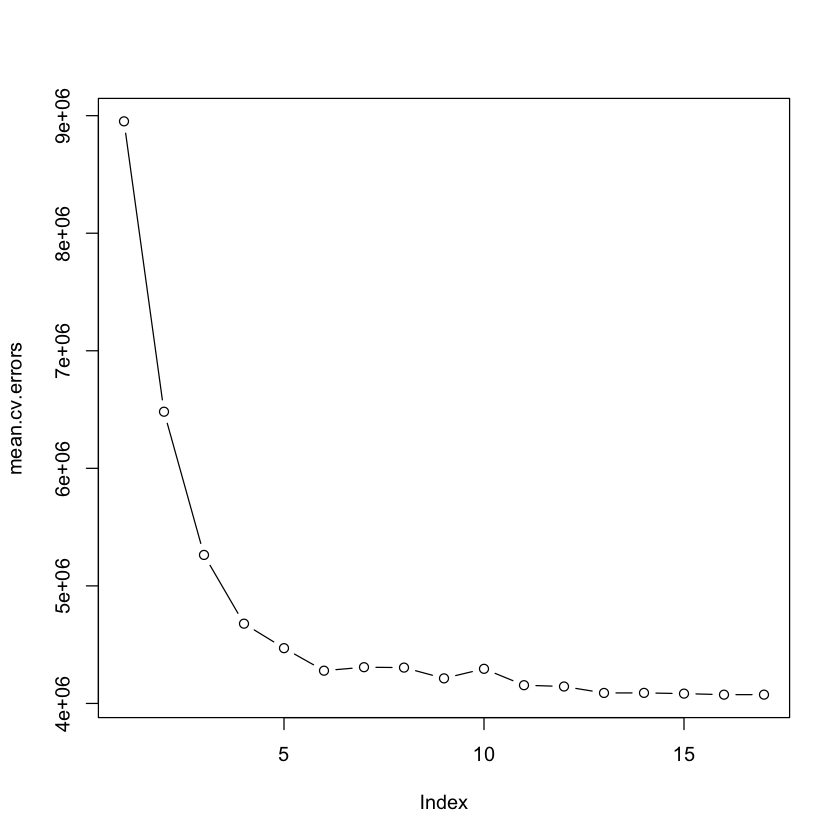

In [20]:
# Calculate the mean cross-validation errors across all folds for each subset size
mean.cv.errors = apply(cv.errors, 2, mean)

# Print the mean cross-validation errors
print(mean.cv.errors)

# Set the plotting layout to a single panel
par(mfrow = c(1, 1))

# Plot the mean cross-validation errors
plot(mean.cv.errors, type = 'b')

**Comment:** Cross-validation selects an 6-variable model, which is consistent with the size that leads to lowest BIC. Although larger model size results slightly lower errors, but the improvement is no longer significant, so we select 6-variable model to reduce the risk of overfit. The predictors are **PrivateYes, Room.Board, PhD, perc.alumni, Expend, Grad.Rate**

(b) Fit a GAM on the training data, using out-of-state tuition as the response and the features selected in the previous step as the predictors. Plot the results, and explain your findings.

In [22]:
# fit GAM model
gam_model <- gam(Outstate ~ Private + s(Room.Board) + s(PhD) + s(perc.alumni) + s(Expend) + s(Grad.Rate),
                 data = College[train,])

# make predictions
predictions <- gam_model %>% predict(College[test,])

# model performance
print(data.frame(
  RMSE = RMSE(predictions, College[test,]$Outstate),
  R2 = R2(predictions, College[test,]$Outstate)
))

     RMSE        R2
1 1876.06 0.7864728


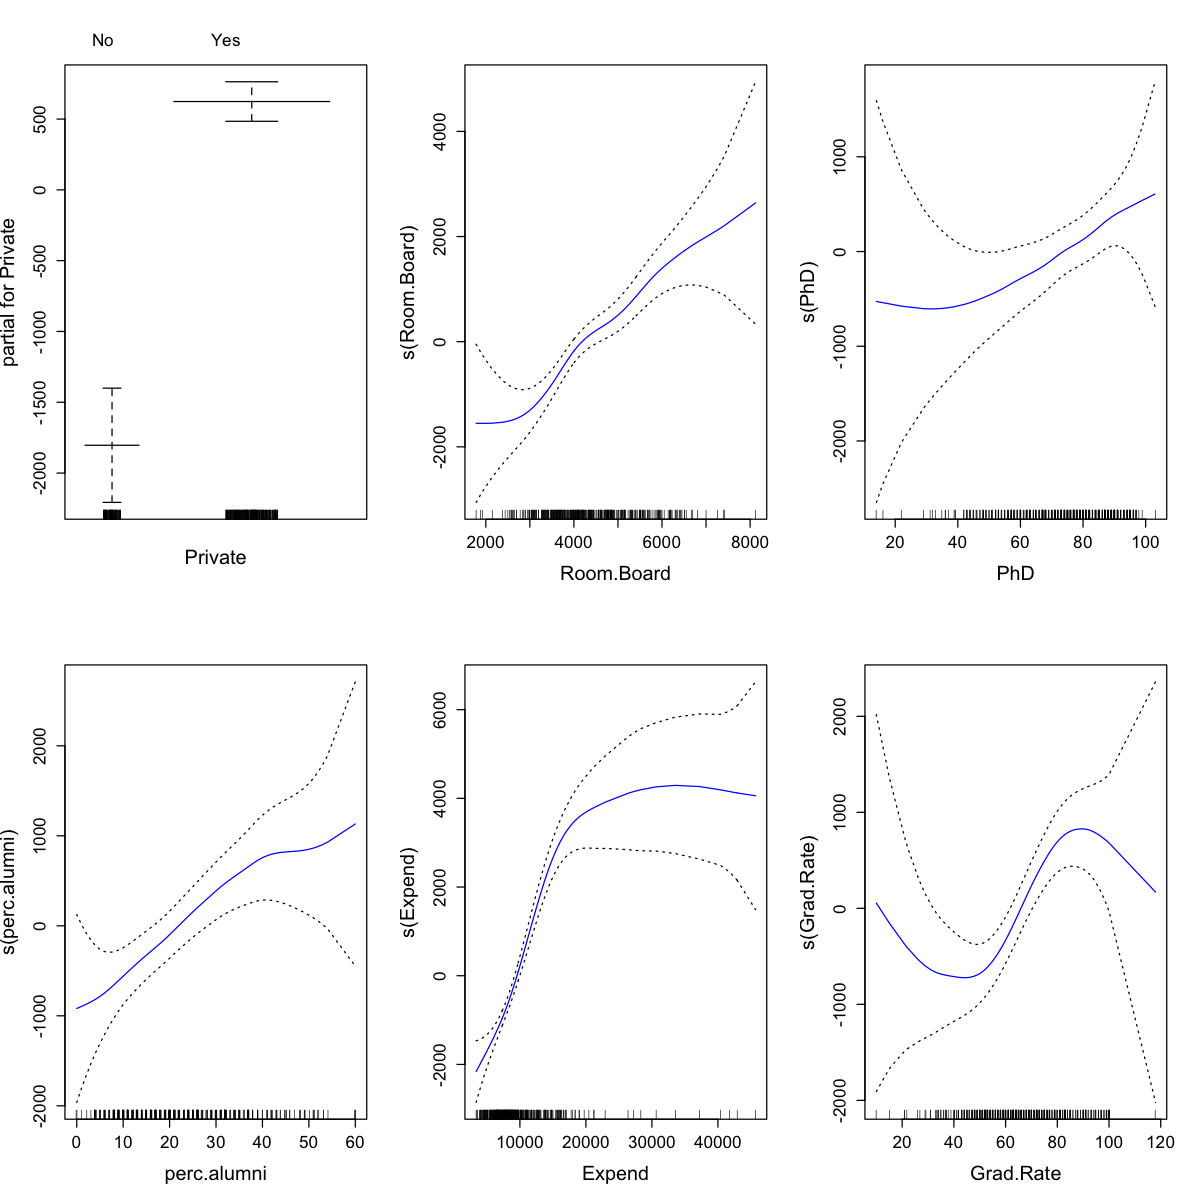

In [36]:
# plot the GAM model

options(repr.plot.width = 10, repr.plot.height = 10)
par(mfrow = c(2,3),
    cex.axis = 1.3,
    cex.lab  = 1.5,
    cex.main = 1.5)
plot(gam_model, se = TRUE, col = "blue")

**Comment:** The plot shows as the value of six predictors increase, they contribute higher fitted Outstate tuition. The higher the cost of Room & Board, percentage of PhD student, percentage of alumni who donate the college, instructional expenditure per student, graduation rate, the higher the Outstate tuition is. The priviate school has obviours higher Outstate tuition than public school.

(c) Evaluate the model obtained on the test set, and explain the results obtained.

(d) For which variables, if any, is there evidence of a non-linear relationship with the response? (make scatterplots of the response against the five numerical predictors.)